# Statistiques des résolutions d'images

Notebook d'exploration pour comparer les résolutions des images entre les différents jeux de données du dossier `datasets/`. Il calcule des résumés par dataset, trace des distributions et exporte les résultats dans `outputs/image_resolution_stats/`.

In [4]:
# 1. Imports et configuration
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, UnidentifiedImageError
from tqdm import tqdm

sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)
pd.set_option("display.max_colwidth", 120)

PROJECT_ROOT = Path.cwd()
DATASETS_ROOT = PROJECT_ROOT / "datasets"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "image_resolution_stats"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

ACCEPTED_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}
MAX_IMAGES_PER_DATASET = None  # Mettre un entier pour accélérer une exploration locale

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"DATASETS_ROOT: {DATASETS_ROOT}")
print(f"OUTPUT_DIR: {OUTPUT_DIR}")

PROJECT_ROOT: /raid/home/students/hawky_luc/P-le-Projet-Zenkolab
DATASETS_ROOT: /raid/home/students/hawky_luc/P-le-Projet-Zenkolab/datasets
OUTPUT_DIR: /raid/home/students/hawky_luc/P-le-Projet-Zenkolab/outputs/image_resolution_stats


In [5]:
# 2. Détection des datasets et collecte des chemins d'images
IGNORED_DATASET_NAMES = {".ipynb_checkpoints", "outputs", "jraigs_subsets", "manit2022__jraigs-dataset", "sshikamaru__glaucoma-detection"}
DATASET_SOURCES = [
    {"name": path.name, "path": path}
    for path in sorted(DATASETS_ROOT.iterdir())
    if path.name not in IGNORED_DATASET_NAMES
] + [
    {
        "name": "FUNDUS_SORTED",
        "path": DATASETS_ROOT / "sshikamaru__glaucoma-detection" / "Fundus_Train_Val_Data" / "Fundus_Scanes_Sorted",
    },
    {
        "name": "ACRIMA",
        "path": DATASETS_ROOT / "sshikamaru__glaucoma-detection" / "ACRIMA",
    },
    {
        "name": "ORIGA",
        "path": DATASETS_ROOT / "sshikamaru__glaucoma-detection" / "ORIGA" / "ORIGA",
    },
]

IMAGE_COLUMNS = [
    "image_path",
    "filepath",
    "path",
    "image",
    "img_path",
    "filename",
    "file",
    "subset_image",
    "kept_image",
    "source_image",
]
LABEL_COLUMNS = ["label", "Label", "final_label", "Final Label"]


def is_image_file(path: Path) -> bool:
    return path.is_file() and path.suffix.lower() in ACCEPTED_EXTENSIONS


def resolve_image_path(raw_value: object, base_dirs: list[Path]) -> Path | None:
    if raw_value is None or pd.isna(raw_value):
        return None

    raw_text = str(raw_value).strip()
    if not raw_text:
        return None

    raw_path = Path(raw_text)
    candidates = [raw_path]
    if not raw_path.is_absolute():
        for base_dir in base_dirs:
            candidates.extend(
                [
                    base_dir / raw_path,
                    base_dir / raw_path.name,
                ]
            )

    for candidate in candidates:
        if is_image_file(candidate):
            return candidate.resolve()

    return None


def collect_records_from_csv(csv_path: Path, dataset_name: str) -> list[dict[str, object]]:
    frame = pd.read_csv(csv_path, low_memory=False)
    image_columns = [column for column in IMAGE_COLUMNS if column in frame.columns]
    label_column = next((column for column in LABEL_COLUMNS if column in frame.columns), None)

    rows: list[dict[str, object]] = []
    for row_index, row in frame.iterrows():
        raw_value = next((row[column] for column in image_columns), None)
        resolved_path = resolve_image_path(raw_value, [csv_path.parent, csv_path.parent.parent, DATASETS_ROOT])
        rows.append(
            {
                "dataset": dataset_name,
                "source_type": "csv",
                "source_file": str(csv_path.relative_to(DATASETS_ROOT)) if csv_path.is_relative_to(DATASETS_ROOT) else str(csv_path),
                "row_index": int(row_index),
                "image_path": str(resolved_path) if resolved_path is not None else (str(raw_value).strip() if raw_value is not None and not pd.isna(raw_value) else None),
                "label": row[label_column] if label_column is not None else None,
            }
        )

    return rows


def collect_records_from_directory(dataset_dir: Path, dataset_name: str | None = None) -> list[dict[str, object]]:
    dataset_label = dataset_name or dataset_dir.name
    csv_candidates = sorted(dataset_dir.rglob("labels*.csv"))
    if not csv_candidates:
        csv_candidates = sorted(dataset_dir.rglob("*.csv"))

    if csv_candidates:
        rows: list[dict[str, object]] = []
        for csv_path in csv_candidates:
            try:
                rows.extend(collect_records_from_csv(csv_path, dataset_label))
            except Exception as exc:
                rows.append(
                    {
                        "dataset": dataset_label,
                        "source_type": "csv_error",
                        "source_file": str(csv_path),
                        "row_index": None,
                        "image_path": None,
                        "label": None,
                        "load_error": str(exc),
                    }
                )
        return rows

    rows = []
    image_files = [path for path in sorted(dataset_dir.rglob("*")) if is_image_file(path)]
    if MAX_IMAGES_PER_DATASET is not None:
        image_files = image_files[:MAX_IMAGES_PER_DATASET]

    for image_path in image_files:
        rows.append(
            {
                "dataset": dataset_label,
                "source_type": "scan",
                "source_file": None,
                "row_index": None,
                "image_path": str(image_path.resolve()),
                "label": None,
            }
        )
    return rows


records: list[dict[str, object]] = []
for dataset_source in tqdm(DATASET_SOURCES, desc="Scanning datasets"):
    dataset_path = dataset_source["path"]
    dataset_name = dataset_source["name"]
    if dataset_path.is_dir():
        records.extend(collect_records_from_directory(dataset_path, dataset_name=dataset_name))
    elif dataset_path.is_file() and dataset_path.suffix.lower() == ".csv":
        records.extend(collect_records_from_csv(dataset_path, dataset_name))

detailed_df = pd.DataFrame(records)
detailed_df = detailed_df.drop_duplicates(subset=["dataset", "image_path"], keep="first").reset_index(drop=True)

print(f"Datasets trouvés: {sorted(detailed_df['dataset'].dropna().unique().tolist())}")
print(f"Nombre total d'entrées: {len(detailed_df):,}")
display(detailed_df.head())

Scanning datasets: 100%|██████████| 6/6 [00:22<00:00,  3.81s/it]


Datasets trouvés: ['ACRIMA', 'FUNDUS_SORTED', 'LAG', 'ORIGA', 'jraigs_prepared', 'victorlemosml__refuge2']
Nombre total d'entrées: 101,070


,dataset,source_type,source_file,row_index,image_path,label
0,LAG,csv,LAG/labels.csv,0,/raid/home/students/hawky_luc/P-le-Projet-Zenkolab/datasets/LAG/train/g.2303.jpg,1
1,LAG,csv,LAG/labels.csv,1,/raid/home/students/hawky_luc/P-le-Projet-Zenkolab/datasets/LAG/train/g.2310.jpg,1
2,LAG,csv,LAG/labels.csv,2,/raid/home/students/hawky_luc/P-le-Projet-Zenkolab/datasets/LAG/train/g.2316.jpg,1
3,LAG,csv,LAG/labels.csv,3,/raid/home/students/hawky_luc/P-le-Projet-Zenkolab/datasets/LAG/train/g.2321.jpg,1
4,LAG,csv,LAG/labels.csv,4,/raid/home/students/hawky_luc/P-le-Projet-Zenkolab/datasets/LAG/train/g.2324.jpg,1


In [6]:
# 3. Chargement sécurisé des images et récupération des résolutions

def safe_image_metadata(image_path: object) -> dict[str, object]:
    if image_path is None or pd.isna(image_path):
        return {
            "width": np.nan,
            "height": np.nan,
            "area": np.nan,
            "aspect_ratio": np.nan,
            "filesize_bytes": np.nan,
            "load_error": "missing_path",
        }

    path = Path(str(image_path))
    try:
        with Image.open(path) as image:
            width, height = image.size
        filesize_bytes = path.stat().st_size if path.exists() else np.nan
        return {
            "width": int(width),
            "height": int(height),
            "area": int(width) * int(height),
            "aspect_ratio": float(width) / float(height) if height else np.nan,
            "filesize_bytes": float(filesize_bytes),
            "load_error": None,
        }
    except (FileNotFoundError, UnidentifiedImageError, OSError, ValueError) as exc:
        return {
            "width": np.nan,
            "height": np.nan,
            "area": np.nan,
            "aspect_ratio": np.nan,
            "filesize_bytes": np.nan,
            "load_error": str(exc),
        }


metadata_rows = [safe_image_metadata(path) for path in tqdm(detailed_df["image_path"], desc="Reading image sizes")]
metadata_df = pd.DataFrame(metadata_rows)
detailed_df = pd.concat([detailed_df, metadata_df], axis=1)
detailed_df["is_valid_image"] = detailed_df[["width", "height"]].notna().all(axis=1)
detailed_df["has_label"] = detailed_df["label"].notna()

print(detailed_df[["dataset", "image_path", "width", "height", "area", "aspect_ratio", "filesize_bytes", "load_error"]].head())
print(f"Images valides: {detailed_df['is_valid_image'].sum():,} / {len(detailed_df):,}")

Reading image sizes: 100%|██████████| 101070/101070 [00:20<00:00, 4898.00it/s]


  dataset                                                                        image_path  width  height    area  aspect_ratio  \
0     LAG  /raid/home/students/hawky_luc/P-le-Projet-Zenkolab/datasets/LAG/train/g.2303.jpg    500     500  250000           1.0   
1     LAG  /raid/home/students/hawky_luc/P-le-Projet-Zenkolab/datasets/LAG/train/g.2310.jpg    500     500  250000           1.0   
2     LAG  /raid/home/students/hawky_luc/P-le-Projet-Zenkolab/datasets/LAG/train/g.2316.jpg    500     500  250000           1.0   
3     LAG  /raid/home/students/hawky_luc/P-le-Projet-Zenkolab/datasets/LAG/train/g.2321.jpg    500     500  250000           1.0   
4     LAG  /raid/home/students/hawky_luc/P-le-Projet-Zenkolab/datasets/LAG/train/g.2324.jpg    500     500  250000           1.0   

   filesize_bytes load_error  
0         64352.0       None  
1         66427.0       None  
2         50973.0       None  
3         50037.0       None  
4         50267.0       None  
Images valides: 101,0

In [7]:
# 4. Calcul des statistiques descriptives par dataset
valid_df = detailed_df[detailed_df["is_valid_image"]].copy()
summary_rows: list[dict[str, object]] = []

for dataset_name, group in detailed_df.groupby("dataset", dropna=False):
    valid_group = group[group["is_valid_image"]].copy()
    width_series = valid_group["width"].dropna()
    height_series = valid_group["height"].dropna()
    area_series = valid_group["area"].dropna()
    aspect_series = valid_group["aspect_ratio"].dropna()

    if not area_series.empty:
        q1 = area_series.quantile(0.25)
        q3 = area_series.quantile(0.75)
        iqr = q3 - q1
        outlier_mask = (area_series < q1 - 1.5 * iqr) | (area_series > q3 + 1.5 * iqr)
        outlier_count = int(outlier_mask.sum())
    else:
        outlier_count = 0

    summary_rows.append(
        {
            "dataset": dataset_name,
            "num_entries": int(len(group)),
            "num_valid_images": int(len(valid_group)),
            "num_missing_or_unreadable": int(len(group) - len(valid_group)),
            "missing_rate": float((len(group) - len(valid_group)) / len(group)) if len(group) else np.nan,
            "width_mean": float(width_series.mean()) if not width_series.empty else np.nan,
            "width_median": float(width_series.median()) if not width_series.empty else np.nan,
            "width_std": float(width_series.std()) if len(width_series) > 1 else np.nan,
            "width_min": float(width_series.min()) if not width_series.empty else np.nan,
            "width_max": float(width_series.max()) if not width_series.empty else np.nan,
            "height_mean": float(height_series.mean()) if not height_series.empty else np.nan,
            "height_median": float(height_series.median()) if not height_series.empty else np.nan,
            "height_std": float(height_series.std()) if len(height_series) > 1 else np.nan,
            "height_min": float(height_series.min()) if not height_series.empty else np.nan,
            "height_max": float(height_series.max()) if not height_series.empty else np.nan,
            "area_mean": float(area_series.mean()) if not area_series.empty else np.nan,
            "area_median": float(area_series.median()) if not area_series.empty else np.nan,
            "area_std": float(area_series.std()) if len(area_series) > 1 else np.nan,
            "area_min": float(area_series.min()) if not area_series.empty else np.nan,
            "area_max": float(area_series.max()) if not area_series.empty else np.nan,
            "aspect_ratio_mean": float(aspect_series.mean()) if not aspect_series.empty else np.nan,
            "aspect_ratio_median": float(aspect_series.median()) if not aspect_series.empty else np.nan,
            "aspect_ratio_std": float(aspect_series.std()) if len(aspect_series) > 1 else np.nan,
            "aspect_ratio_min": float(aspect_series.min()) if not aspect_series.empty else np.nan,
            "aspect_ratio_max": float(aspect_series.max()) if not aspect_series.empty else np.nan,
            "filesize_mean": float(valid_group["filesize_bytes"].mean()) if not valid_group.empty else np.nan,
            "filesize_median": float(valid_group["filesize_bytes"].median()) if not valid_group.empty else np.nan,
            "outlier_area_count": outlier_count,
            "label_available_rate": float(group["has_label"].mean()) if len(group) else np.nan,
        }
    )

summary_df = pd.DataFrame(summary_rows).sort_values("num_valid_images", ascending=False).reset_index(drop=True)
display(summary_df)

print("Datasets classés par nombre d'images valides:")
print(summary_df[["dataset", "num_valid_images", "missing_rate"]].to_string(index=False))

,dataset,num_entries,num_valid_images,num_missing_or_unreadable,missing_rate,width_mean,width_median,width_std,width_min,width_max,height_mean,height_median,height_std,height_min,height_max,area_mean,area_median,area_std,area_min,area_max,aspect_ratio_mean,aspect_ratio_median,aspect_ratio_std,aspect_ratio_min,aspect_ratio_max,filesize_mean,filesize_median,outlier_area_count,label_available_rate
0,jraigs_prepared,93011,93011,0,0.0,3302.141639,3088.0,1000.986185,320.0,6000.0,2357.723484,2136.0,544.249732,212.0,4000.0,8.309812e+06,6348928.0,4.521975e+06,67840.0,24000000.0,1.381556,1.333333,0.155517,1.0,1.513514,6.467303e+05,542295.0,2660,1.000000
1,LAG,4854,4854,0,0.0,500.000000,500.0,0.000000,500.0,500.0,500.000000,500.0,0.000000,500.0,500.0,2.500000e+05,250000.0,0.000000e+00,250000.0,250000.0,1.000000,1.000000,0.000000,1.0,1.000000,6.383228e+04,62838.0,0,1.000000
2,victorlemosml__refuge2,1200,1200,0,0.0,1899.333333,1940.0,202.182146,1634.0,2124.0,1876.666667,1940.0,178.080458,1634.0,2056.0,3.600167e+06,3763600.0,7.026578e+05,2669956.0,4366944.0,1.011025,1.000000,0.015598,1.0,1.033074,1.147209e+06,921233.5,0,0.333333
3,ACRIMA,705,705,0,0.0,529.719149,424.0,243.509685,178.0,1420.0,529.009929,421.0,243.053518,178.0,1420.0,3.392947e+05,179776.0,3.147314e+05,31684.0,2016400.0,1.001142,1.000000,0.013445,1.0,1.300336,3.633905e+04,23467.0,17,1.000000
4,FUNDUS_SORTED,650,650,0,0.0,3072.020000,3072.0,0.509902,3072.0,3085.0,2048.000000,2048.0,0.000000,2048.0,2048.0,6.291497e+06,6291456.0,1.044279e+03,6291456.0,6318080.0,1.500010,1.500000,0.000249,1.5,1.506348,3.171405e+05,307881.5,1,1.000000
5,ORIGA,650,650,0,0.0,3072.020000,3072.0,0.509902,3072.0,3085.0,2048.000000,2048.0,0.000000,2048.0,2048.0,6.291497e+06,6291456.0,1.044279e+03,6291456.0,6318080.0,1.500010,1.500000,0.000249,1.5,1.506348,3.171405e+05,307881.5,1,1.000000


Datasets classés par nombre d'images valides:
               dataset  num_valid_images  missing_rate
       jraigs_prepared             93011           0.0
                   LAG              4854           0.0
victorlemosml__refuge2              1200           0.0
                ACRIMA               705           0.0
         FUNDUS_SORTED               650           0.0
                 ORIGA               650           0.0


/tmp/ipykernel_1468503/2093716614.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x="dataset", y="width", ax=axes[0], palette="Blues")
/tmp/ipykernel_1468503/2093716614.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x="dataset", y="height", ax=axes[1], palette="Greens")


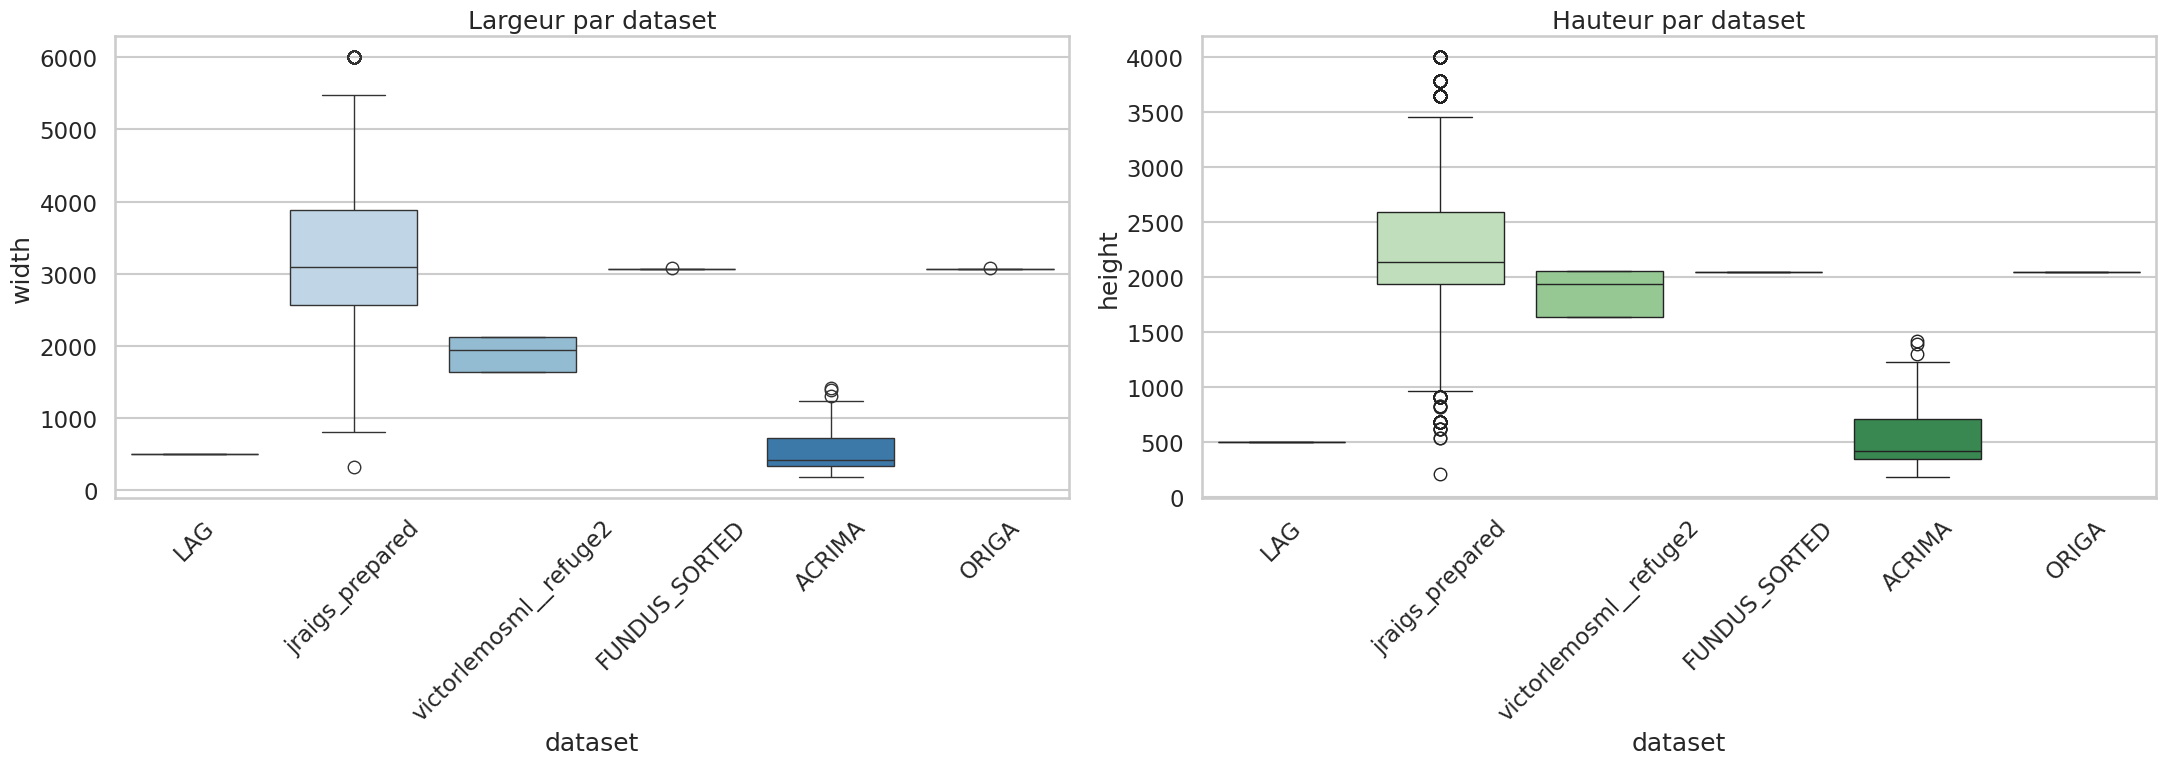

Saved: /raid/home/students/hawky_luc/P-le-Projet-Zenkolab/outputs/image_resolution_stats/width_height_boxplots.png


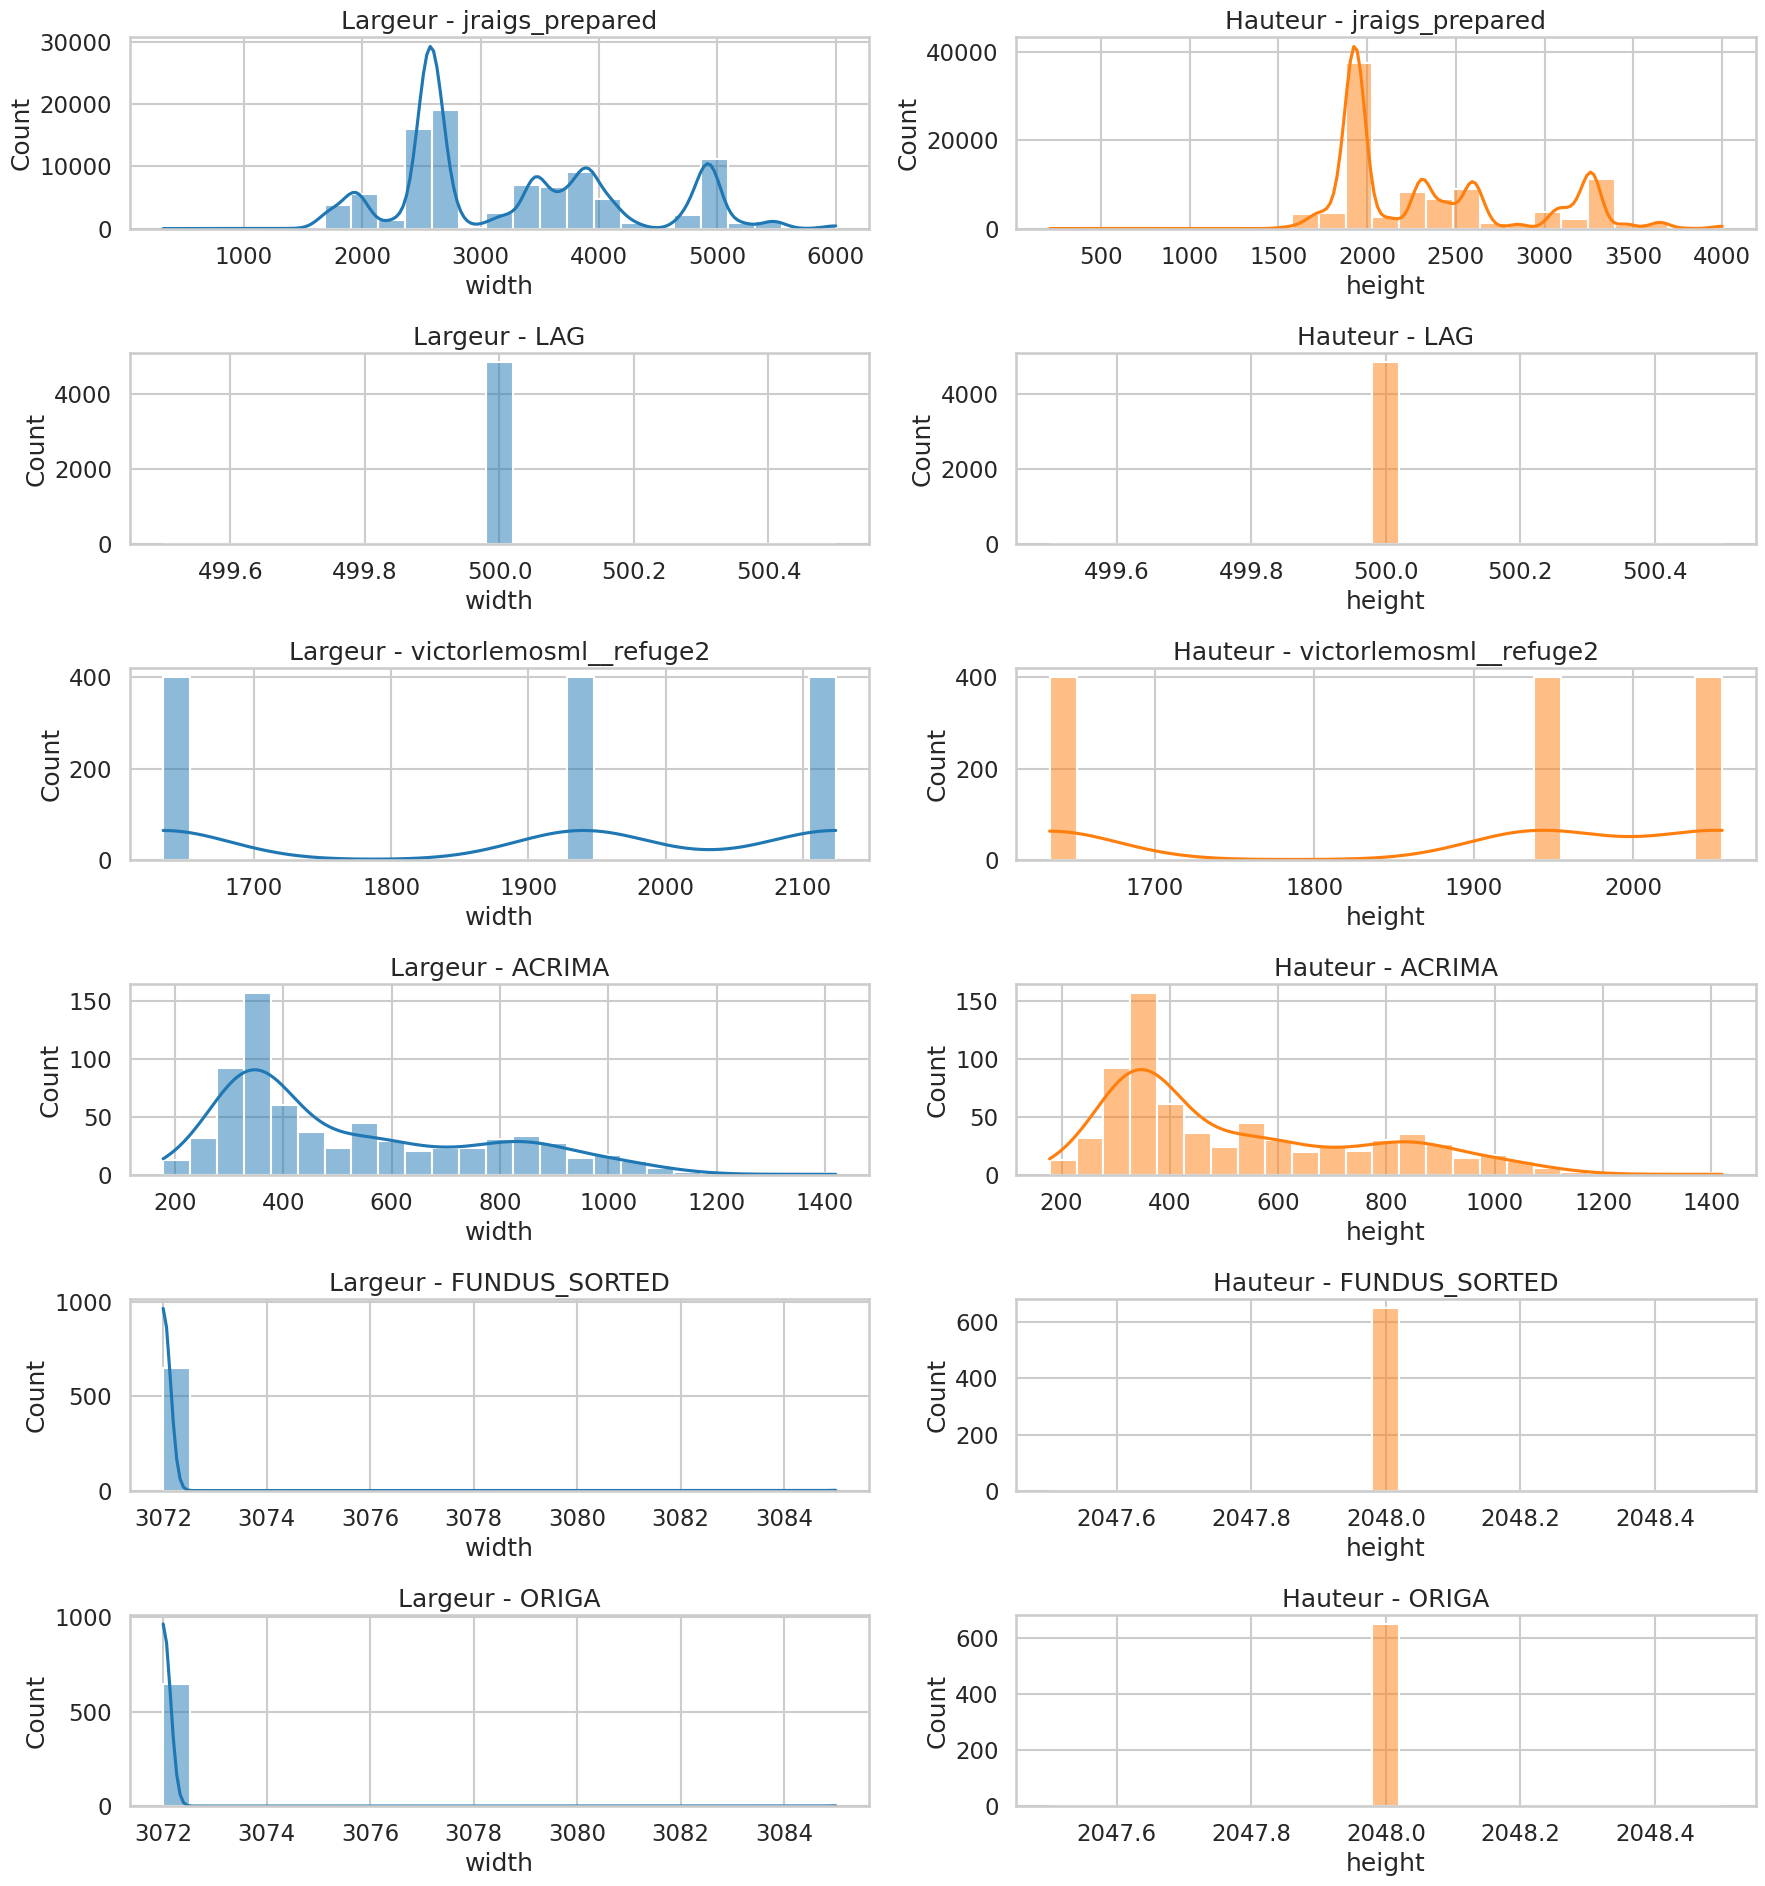

Saved: /raid/home/students/hawky_luc/P-le-Projet-Zenkolab/outputs/image_resolution_stats/width_height_histograms_by_dataset.png


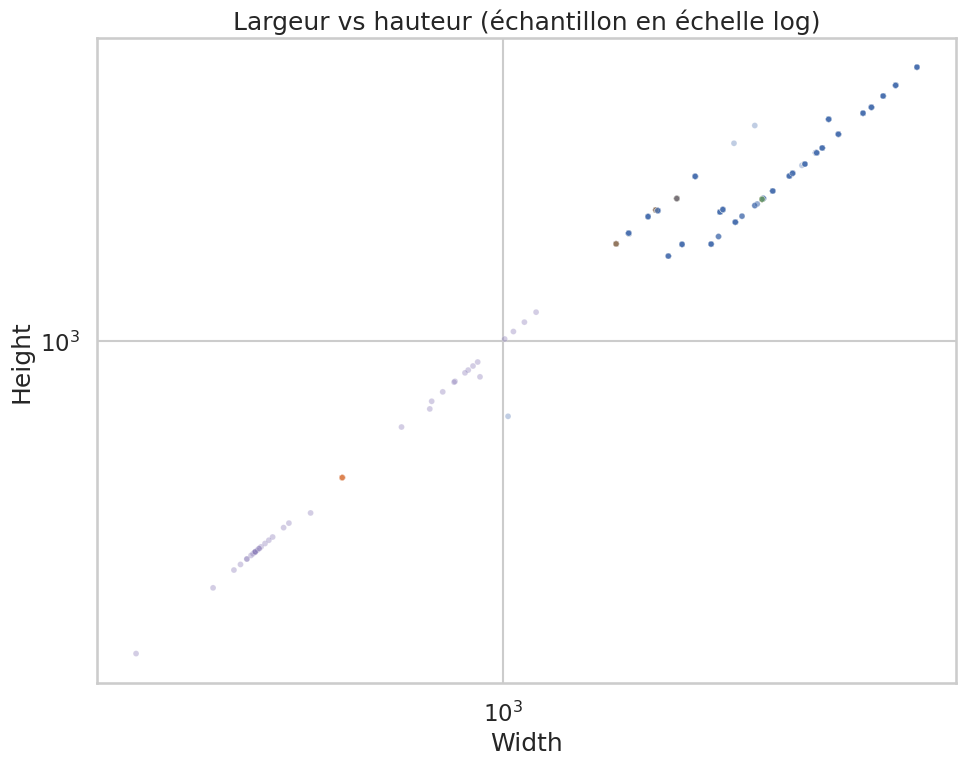

Saved: /raid/home/students/hawky_luc/P-le-Projet-Zenkolab/outputs/image_resolution_stats/width_vs_height_scatter.png


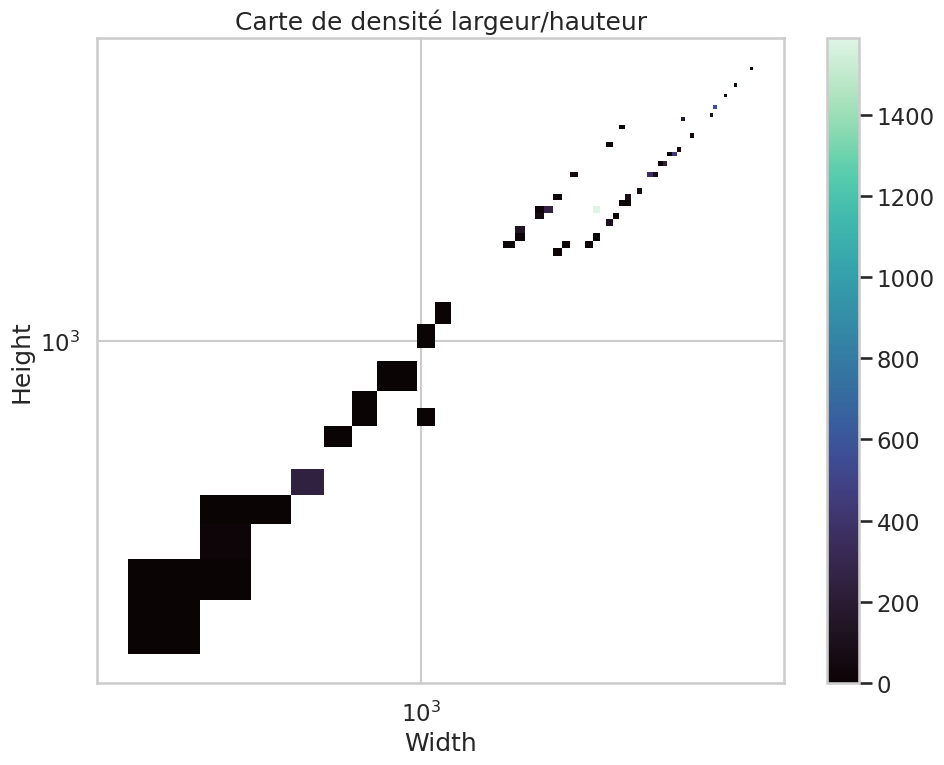

Saved: /raid/home/students/hawky_luc/P-le-Projet-Zenkolab/outputs/image_resolution_stats/width_height_density_heatmap.png


In [8]:
# 5. Visualisations (histogrammes, boxplots, scatter width vs height)

def save_figure(filename: str) -> Path:
    path = OUTPUT_DIR / filename
    plt.tight_layout()
    plt.savefig(path, dpi=160, bbox_inches="tight")
    plt.show()
    plt.close()
    return path


TOP_DATASETS = summary_df.head(8)["dataset"].tolist()
plot_df = valid_df[valid_df["dataset"].isin(TOP_DATASETS)].copy()

if not plot_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(22, 8))
    sns.boxplot(data=plot_df, x="dataset", y="width", ax=axes[0], palette="Blues")
    axes[0].set_title("Largeur par dataset")
    axes[0].tick_params(axis="x", rotation=45)

    sns.boxplot(data=plot_df, x="dataset", y="height", ax=axes[1], palette="Greens")
    axes[1].set_title("Hauteur par dataset")
    axes[1].tick_params(axis="x", rotation=45)
    width_height_boxplot_path = save_figure("width_height_boxplots.png")
    print(f"Saved: {width_height_boxplot_path}")

    width_hist_rows = len(TOP_DATASETS)
    fig, axes = plt.subplots(width_hist_rows, 2, figsize=(18, 3.2 * width_hist_rows), sharex=False)
    if width_hist_rows == 1:
        axes = np.array([axes])
    for row_axis, dataset_name in zip(axes, TOP_DATASETS):
        dataset_df = plot_df[plot_df["dataset"] == dataset_name]
        sns.histplot(dataset_df["width"], kde=True, bins=25, ax=row_axis[0], color="#1f77b4")
        row_axis[0].set_title(f"Largeur - {dataset_name}")
        sns.histplot(dataset_df["height"], kde=True, bins=25, ax=row_axis[1], color="#ff7f0e")
        row_axis[1].set_title(f"Hauteur - {dataset_name}")
    width_height_hist_path = save_figure("width_height_histograms_by_dataset.png")
    print(f"Saved: {width_height_hist_path}")

sample_size = min(5000, len(valid_df))
scatter_df = valid_df.sample(sample_size, random_state=42).copy() if sample_size else valid_df.copy()
if not scatter_df.empty:
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.scatterplot(data=scatter_df, x="width", y="height", hue="dataset", alpha=0.35, s=18, ax=ax, legend=False)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_title("Largeur vs hauteur (échantillon en échelle log)")
    ax.set_xlabel("Width")
    ax.set_ylabel("Height")
    scatter_path = save_figure("width_vs_height_scatter.png")
    print(f"Saved: {scatter_path}")

    fig, ax = plt.subplots(figsize=(10, 8))
    density = sns.histplot(data=scatter_df, x="width", y="height", bins=60, pmax=0.98, cmap="mako", cbar=True, ax=ax)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_title("Carte de densité largeur/hauteur")
    ax.set_xlabel("Width")
    ax.set_ylabel("Height")
    density_path = save_figure("width_height_density_heatmap.png")
    print(f"Saved: {density_path}")


,dataset,label_str,num_images,width_mean,width_median,height_mean,height_median,area_mean,aspect_ratio_mean
0,ACRIMA,0,309,352.912621,346.0,352.912621,346.0,1.271083e+05,1.000000
1,ACRIMA,1,396,667.681818,673.0,666.419192,668.5,5.048643e+05,1.002034
2,FUNDUS_SORTED,0,482,3072.000000,3072.0,2048.000000,2048.0,6.291456e+06,1.500000
3,FUNDUS_SORTED,1,168,3072.077381,3072.0,2048.000000,2048.0,6.291614e+06,1.500038
4,LAG,0,3143,500.000000,500.0,500.000000,500.0,2.500000e+05,1.000000
5,LAG,1,1711,500.000000,500.0,500.000000,500.0,2.500000e+05,1.000000
6,ORIGA,0,482,3072.000000,3072.0,2048.000000,2048.0,6.291456e+06,1.500000
7,ORIGA,1,168,3072.077381,3072.0,2048.000000,2048.0,6.291614e+06,1.500038
8,jraigs_prepared,NRG,90733,3300.074306,3088.0,2356.763846,2136.0,8.303199e+06,1.381223
9,jraigs_prepared,RG,2278,3384.483758,3456.0,2395.946005,2304.0,8.573241e+06,1.394808


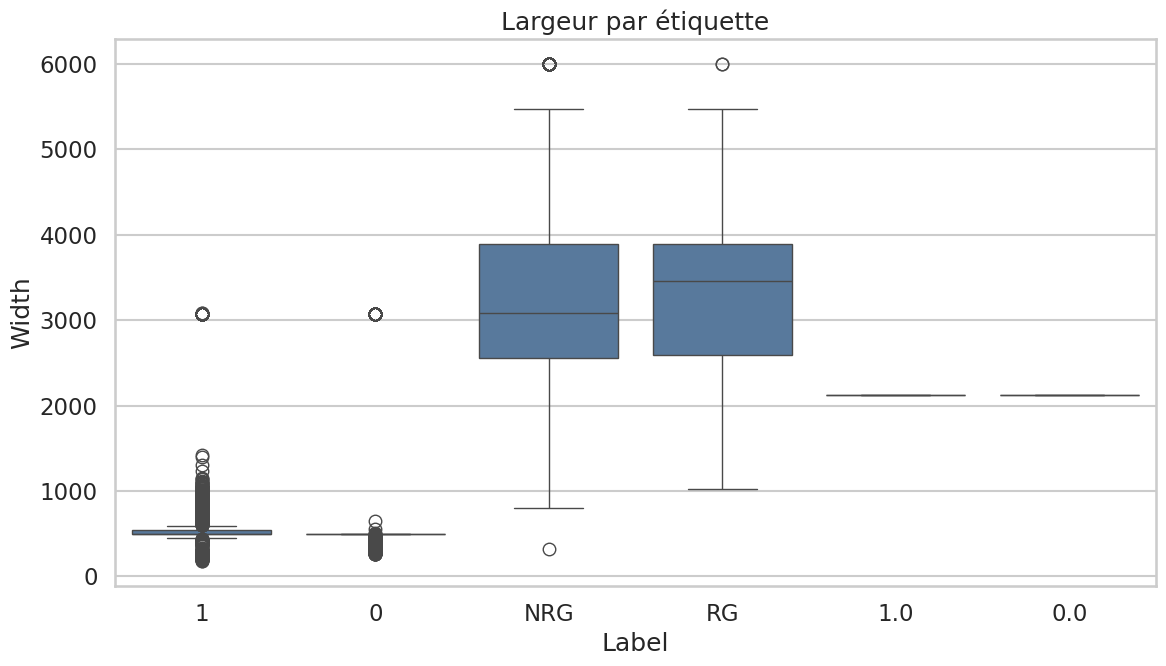

Saved: /raid/home/students/hawky_luc/P-le-Projet-Zenkolab/outputs/image_resolution_stats/width_by_label.png
Saved: /raid/home/students/hawky_luc/P-le-Projet-Zenkolab/outputs/image_resolution_stats/image_resolution_details.csv
Saved: /raid/home/students/hawky_luc/P-le-Projet-Zenkolab/outputs/image_resolution_stats/image_resolution_summary.csv
Saved: /raid/home/students/hawky_luc/P-le-Projet-Zenkolab/outputs/image_resolution_stats/image_resolution_by_label.csv
Saved: /raid/home/students/hawky_luc/P-le-Projet-Zenkolab/outputs/image_resolution_stats/image_resolution_report.json
{
  "project_root": "/raid/home/students/hawky_luc/P-le-Projet-Zenkolab",
  "datasets_root": "/raid/home/students/hawky_luc/P-le-Projet-Zenkolab/datasets",
  "num_datasets": 6,
  "num_entries": 101070,
  "num_valid_images": 101070,
  "num_unreadable_or_missing": 0,
  "output_dir": "/raid/home/students/hawky_luc/P-le-Projet-Zenkolab/outputs/image_resolution_stats",
  "files": {
    "details_csv": "/raid/home/students

In [9]:
# 6. Analyse par classe/étiquette (si disponible dans CSV)
label_df = valid_df[valid_df["has_label"]].copy()
label_summary_df = pd.DataFrame()

if not label_df.empty:
    label_df["label_str"] = label_df["label"].astype(str)
    label_summary_df = (
        label_df.groupby(["dataset", "label_str"], dropna=False)
        .agg(
            num_images=("image_path", "size"),
            width_mean=("width", "mean"),
            width_median=("width", "median"),
            height_mean=("height", "mean"),
            height_median=("height", "median"),
            area_mean=("area", "mean"),
            aspect_ratio_mean=("aspect_ratio", "mean"),
        )
        .reset_index()
        .sort_values(["dataset", "label_str"])
    )
    display(label_summary_df)

    fig, ax = plt.subplots(figsize=(12, 7))
    if label_df["dataset"].nunique() <= 5:
        sns.boxplot(data=label_df, x="label_str", y="width", hue="dataset", ax=ax)
        ax.legend(title="dataset", bbox_to_anchor=(1.02, 1), loc="upper left")
    else:
        sns.boxplot(data=label_df, x="label_str", y="width", ax=ax, color="#4C78A8")
    ax.set_title("Largeur par étiquette")
    ax.set_xlabel("Label")
    ax.set_ylabel("Width")
    label_width_path = save_figure("width_by_label.png")
    print(f"Saved: {label_width_path}")
else:
    print("Aucune colonne d'étiquette exploitable n'a été trouvée dans les CSV chargés.")

# 7. Export des résultats (CSV/JSON) et sauvegarde des figures
DETAIL_CSV = OUTPUT_DIR / "image_resolution_details.csv"
SUMMARY_CSV = OUTPUT_DIR / "image_resolution_summary.csv"
LABEL_CSV = OUTPUT_DIR / "image_resolution_by_label.csv"
REPORT_JSON = OUTPUT_DIR / "image_resolution_report.json"

export_df = detailed_df.copy()
export_df.to_csv(DETAIL_CSV, index=False)
summary_df.to_csv(SUMMARY_CSV, index=False)
if not label_summary_df.empty:
    label_summary_df.to_csv(LABEL_CSV, index=False)

report = {
    "project_root": str(PROJECT_ROOT),
    "datasets_root": str(DATASETS_ROOT),
    "num_datasets": int(detailed_df["dataset"].nunique()),
    "num_entries": int(len(detailed_df)),
    "num_valid_images": int(detailed_df["is_valid_image"].sum()),
    "num_unreadable_or_missing": int((~detailed_df["is_valid_image"]).sum()),
    "output_dir": str(OUTPUT_DIR),
    "files": {
        "details_csv": str(DETAIL_CSV),
        "summary_csv": str(SUMMARY_CSV),
        "label_csv": str(LABEL_CSV),
    },
}
REPORT_JSON.write_text(json.dumps(report, ensure_ascii=False, indent=2), encoding="utf-8")

print(f"Saved: {DETAIL_CSV}")
print(f"Saved: {SUMMARY_CSV}")
if not label_summary_df.empty:
    print(f"Saved: {LABEL_CSV}")
print(f"Saved: {REPORT_JSON}")
print(json.dumps(report, ensure_ascii=False, indent=2))

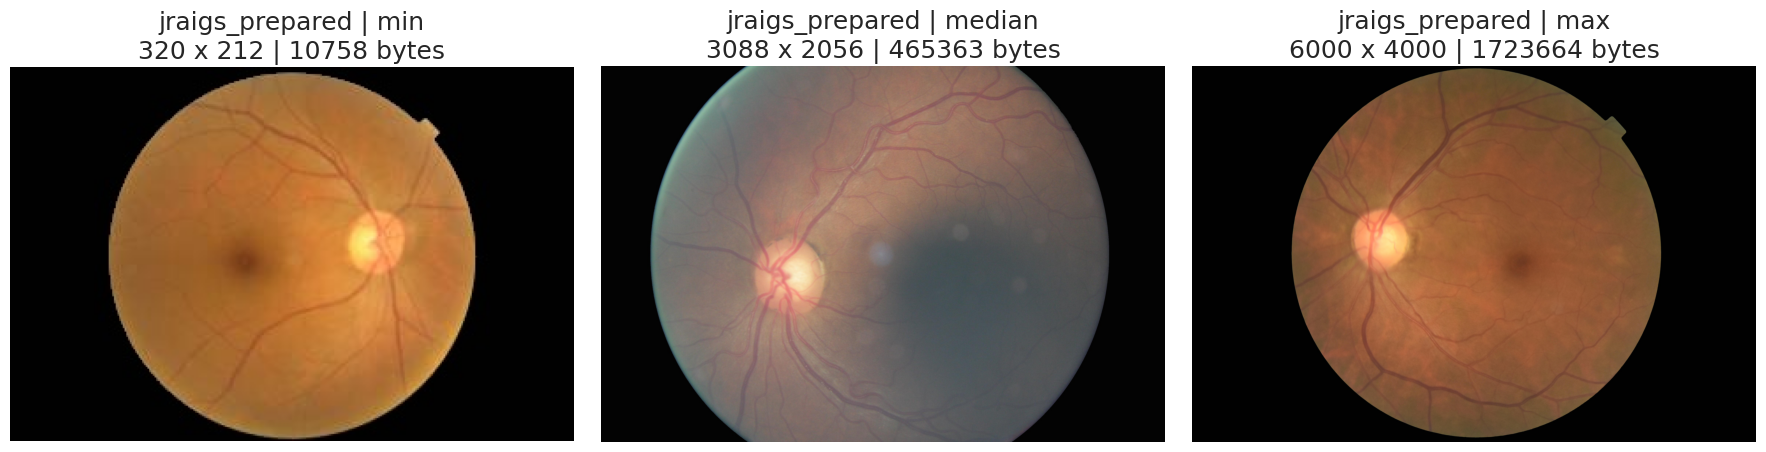

Saved: /raid/home/students/hawky_luc/P-le-Projet-Zenkolab/outputs/image_resolution_stats/representative_jraigs_prepared.png


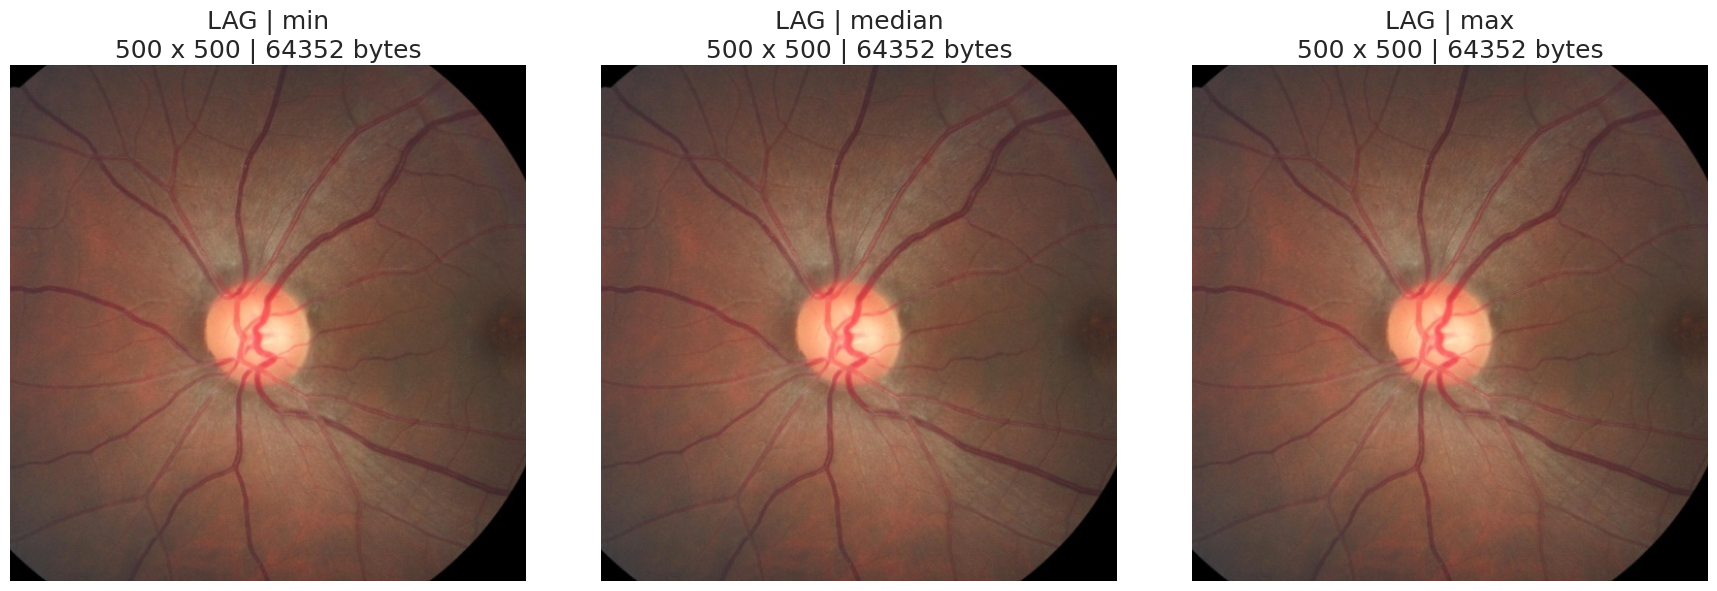

Saved: /raid/home/students/hawky_luc/P-le-Projet-Zenkolab/outputs/image_resolution_stats/representative_LAG.png


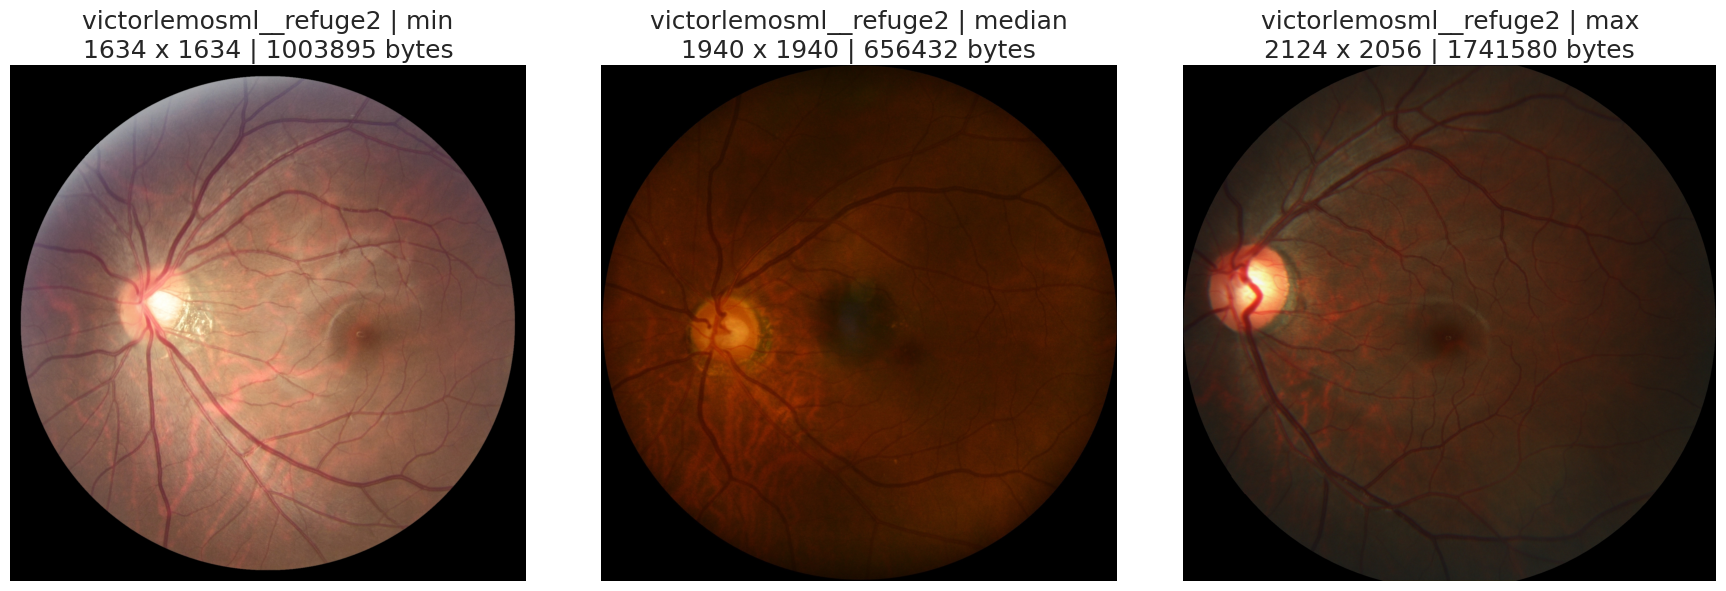

Saved: /raid/home/students/hawky_luc/P-le-Projet-Zenkolab/outputs/image_resolution_stats/representative_victorlemosml__refuge2.png


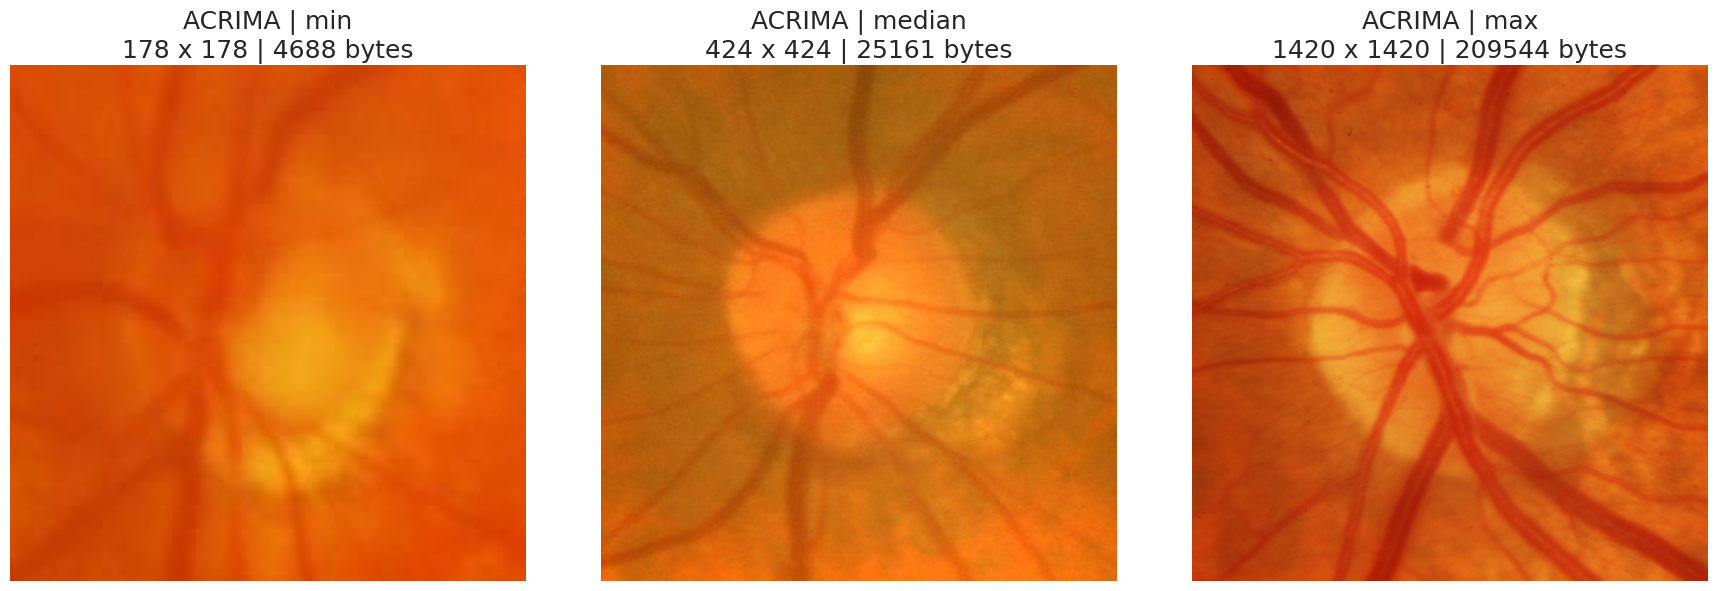

Saved: /raid/home/students/hawky_luc/P-le-Projet-Zenkolab/outputs/image_resolution_stats/representative_ACRIMA.png


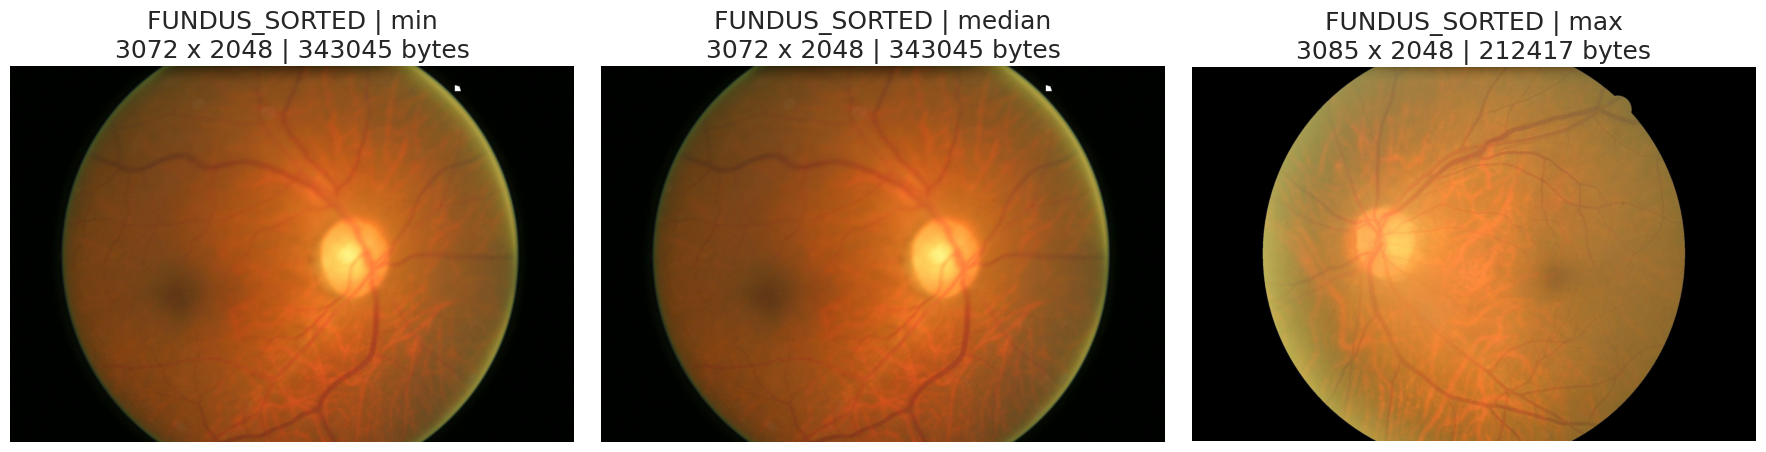

Saved: /raid/home/students/hawky_luc/P-le-Projet-Zenkolab/outputs/image_resolution_stats/representative_FUNDUS_SORTED.png
Assertions OK.
Images non validées: 0


In [10]:
# 8. Affichage d'échantillons représentatifs (résolutions min/max/médiane)

def display_representative_images(dataset_name: str, group: pd.DataFrame) -> None:
    group = group[group["is_valid_image"]].copy()
    if group.empty:
        print(f"{dataset_name}: aucune image valide à afficher.")
        return

    group["distance_to_median_area"] = (group["area"] - group["area"].median()).abs()
    representatives = {
        "min": group.loc[group["area"].idxmin()],
        "median": group.loc[group["distance_to_median_area"].idxmin()],
        "max": group.loc[group["area"].idxmax()],
    }

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    for axis, (rank, row) in zip(axes, representatives.items()):
        image_path = Path(row["image_path"])
        with Image.open(image_path) as image:
            axis.imshow(image)
        axis.axis("off")
        axis.set_title(
            f"{dataset_name} | {rank}\n{int(row['width'])} x {int(row['height'])} | {int(row['filesize_bytes']) if pd.notna(row['filesize_bytes']) else 'NA'} bytes"
        )
    representative_path = OUTPUT_DIR / f"representative_{dataset_name.replace('/', '_')}.png"
    plt.tight_layout()
    plt.savefig(representative_path, dpi=160, bbox_inches="tight")
    plt.show()
    plt.close()
    print(f"Saved: {representative_path}")


for dataset_name in TOP_DATASETS[:5]:
    display_representative_images(dataset_name, valid_df[valid_df["dataset"] == dataset_name])

# 9. Tests / assertions rapides pour valider les données
assert not valid_df.empty, "Aucune image valide n'a pu être lue."
assert valid_df["width"].gt(0).all(), "Des largeurs non positives ont été détectées."
assert valid_df["height"].gt(0).all(), "Des hauteurs non positives ont été détectées."
assert valid_df["aspect_ratio"].between(0.05, 20.0).all(), "Des ratios largeur/hauteur aberrants ont été détectés."

print("Assertions OK.")
print(f"Images non validées: {(~detailed_df['is_valid_image']).sum():,}")

## Notes d'utilisation

Si le notebook est ouvert dans un autre dossier, adapte `PROJECT_ROOT` dans la cellule d'imports et configuration, ou remplace `Path.cwd()` par le chemin absolu du projet. Tu peux aussi réduire `MAX_IMAGES_PER_DATASET` pour accélérer une exploration locale sur de gros volumes d'images.